In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kaggle

In [5]:
kaggle.api.authenticate()
kaggle.api.dataset_download_files(
    'yasserh/breast-cancer-dataset',
    unzip =True,
    path ='C:\MACHINE LEARNING ADVANCE\SVM'
)

<>:5: SyntaxWarning: invalid escape sequence '\M'
<>:5: SyntaxWarning: invalid escape sequence '\M'
C:\Users\NIKHI\AppData\Local\Temp\ipykernel_23644\2096583689.py:5: SyntaxWarning: invalid escape sequence '\M'
  path ='C:\MACHINE LEARNING ADVANCE\SVM'


Dataset URL: https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset


In [6]:
df = pd.read_csv(r'SVM/breast-cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
df.drop(columns=['id'], inplace = True)

In [8]:
X = df.iloc[:,1:]
y= df.iloc[:,0]

In [10]:
from sklearn.model_selection import train_test_split
X_train ,X_test, y_train,y_test = train_test_split(X,
                                                   y,
                                                   test_size = 0.2,
                                                   random_state =42)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
X_train_scaled

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]], shape=(455, 30))

In [14]:
type(X_train_scaled)

numpy.ndarray

In [16]:
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

### BASELINE LINEAR SVM

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score , classification_report
linear_svm = SVC(kernel = 'linear', C =1.0, random_state =42)
linear_svm.fit(X_train_scaled, y_train_encoded)
y_pred = linear_svm.predict(X_test_scaled)


In [27]:
y_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1])

In [29]:
print("accuracy_score", accuracy_score(y_test_encoded, y_pred))
print("support vectors per class", linear_svm.n_support_)

accuracy_score 0.956140350877193
support vectors per class [20 16]


In [21]:
linear_svm.coef_

array([[ 0.3547182 ,  0.05407918,  0.27841613,  0.22435288, -0.05513569,
        -0.75410654,  0.65163147,  1.41650461, -0.15897   ,  0.13477067,
         1.01381006, -0.37168265,  0.20192331,  0.77440381,  0.33479408,
        -0.36820645, -0.24462673,  0.18436516, -0.39191077, -0.60305658,
         0.59782035,  1.1928433 ,  0.11793292,  0.55025799,  0.23050889,
        -0.15264298,  0.75127862,  0.11355058,  0.80239445,  0.52539728]])

In [30]:
linear_svm.coef_.shape

(1, 30)

In [32]:
linear_svm.ndim()

AttributeError: 'SVC' object has no attribute 'ndim'

In [ ]:
import numpy as np
w_norm = np.linalg.norm(linear_svm.coef_[0])
print("||w|| =", w_norm)
print("Margin width (2/||w||) =", 2 / w_norm)

||w|| = 3.104616340935059
Margin width (2/||w||) = 0.644201981942037


### RBF kernel + tuning 

 ### general template for grid search 
 from sklearn.model_selection import GridSearchCV

# 1. Define parameter grid
param_grid = {
    # 'parameter_name': [list of values]
}

# 2. Create GridSearchCV object
grid = GridSearchCV(
    estimator=model,              # e.g., SVC(), RandomForestClassifier()
    param_grid=param_grid,
    cv=5,                         # Number of cross-validation folds
    scoring='accuracy',           # Change according to problem
    n_jobs=-1,                    # Use all CPU cores
    verbose=1,                    # Shows training progress
    refit=True                    # Retrain best model on full training set
)

# 3. Fit on training data
grid.fit(X_train, y_train)

# 4. Best hyperparameters
print("Best Parameters:", grid.best_params_)

# 5. Best cross-validation score
print("Best CV Score:", grid.best_score_)

# 6. Best model
best_model = grid.best_estimator_

# 7. Predictions
y_pred = best_model.predict(X_test)

# 8. Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 'scale'],
    'kernel': ['rbf']
}
grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
best_svm = grid.best_estimator_
rbf_pred = best_svm.predict(X_test_scaled)
print("Test accuracy:", accuracy_score(y_test, rbf_pred))
print(classification_report(y_test, rbf_pred))

Best params: {'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}
Test accuracy: 0.8070175438596491
              precision    recall  f1-score   support

           B       0.76      1.00      0.87        71
           M       1.00      0.49      0.66        43

    accuracy                           0.81       114
   macro avg       0.88      0.74      0.76       114
weighted avg       0.85      0.81      0.79       114



c:\MACHINE LEARNING ADVANCE\mlenv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


In [23]:
best_svm

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


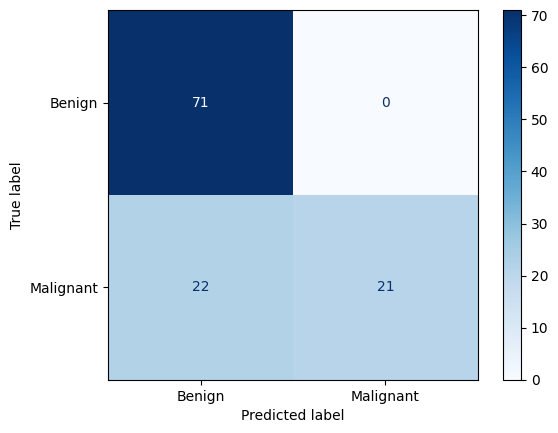

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, rbf_pred, display_labels=['Benign','Malignant'], cmap='Blues')

In [25]:
from sklearn.metrics import roc_auc_score, roc_curve

scores = best_svm.decision_function(X_test_scaled)
auc = roc_auc_score(y_test, scores)
print("ROC-AUC:", auc)

ROC-AUC: 0.9980347199475925


In [33]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = [

    # Linear Kernel
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100]
    },

    # RBF Kernel
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1]
    },

    # Polynomial Kernel
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'degree': [2, 3, 4],
        'gamma': ['scale', 'auto']
    },

    # Sigmoid Kernel
    {
        'kernel': ['sigmoid'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto']
    }

]

grid = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)

{'C': 0.1, 'kernel': 'linear'}


ROC-AUC: 0.9980347199475925


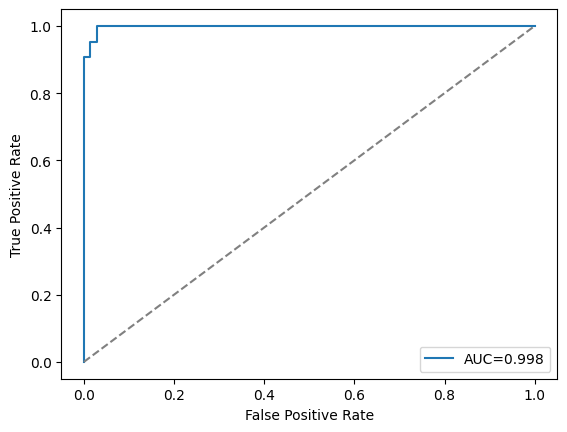

In [34]:
from sklearn.metrics import roc_auc_score, roc_curve

scores = best_svm.decision_function(X_test_scaled)
auc = roc_auc_score(y_test_encoded, scores)
print("ROC-AUC:", auc)

fpr, tpr, _ = roc_curve(y_test_encoded, scores)
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()